In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4512
Epoca [10/100] | Loss: 0.1993
Epoca [20/100] | Loss: 0.0574
Epoca [30/100] | Loss: 0.0224
Epoca [40/100] | Loss: 0.0111
Epoca [50/100] | Loss: 0.0068
Epoca [60/100] | Loss: 0.0050
Epoca [70/100] | Loss: 0.0039
Epoca [80/100] | Loss: 0.0035
Epoca [90/100] | Loss: 0.0032
Epoca [100/100] | Loss: 0.0030

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0064
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0001


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

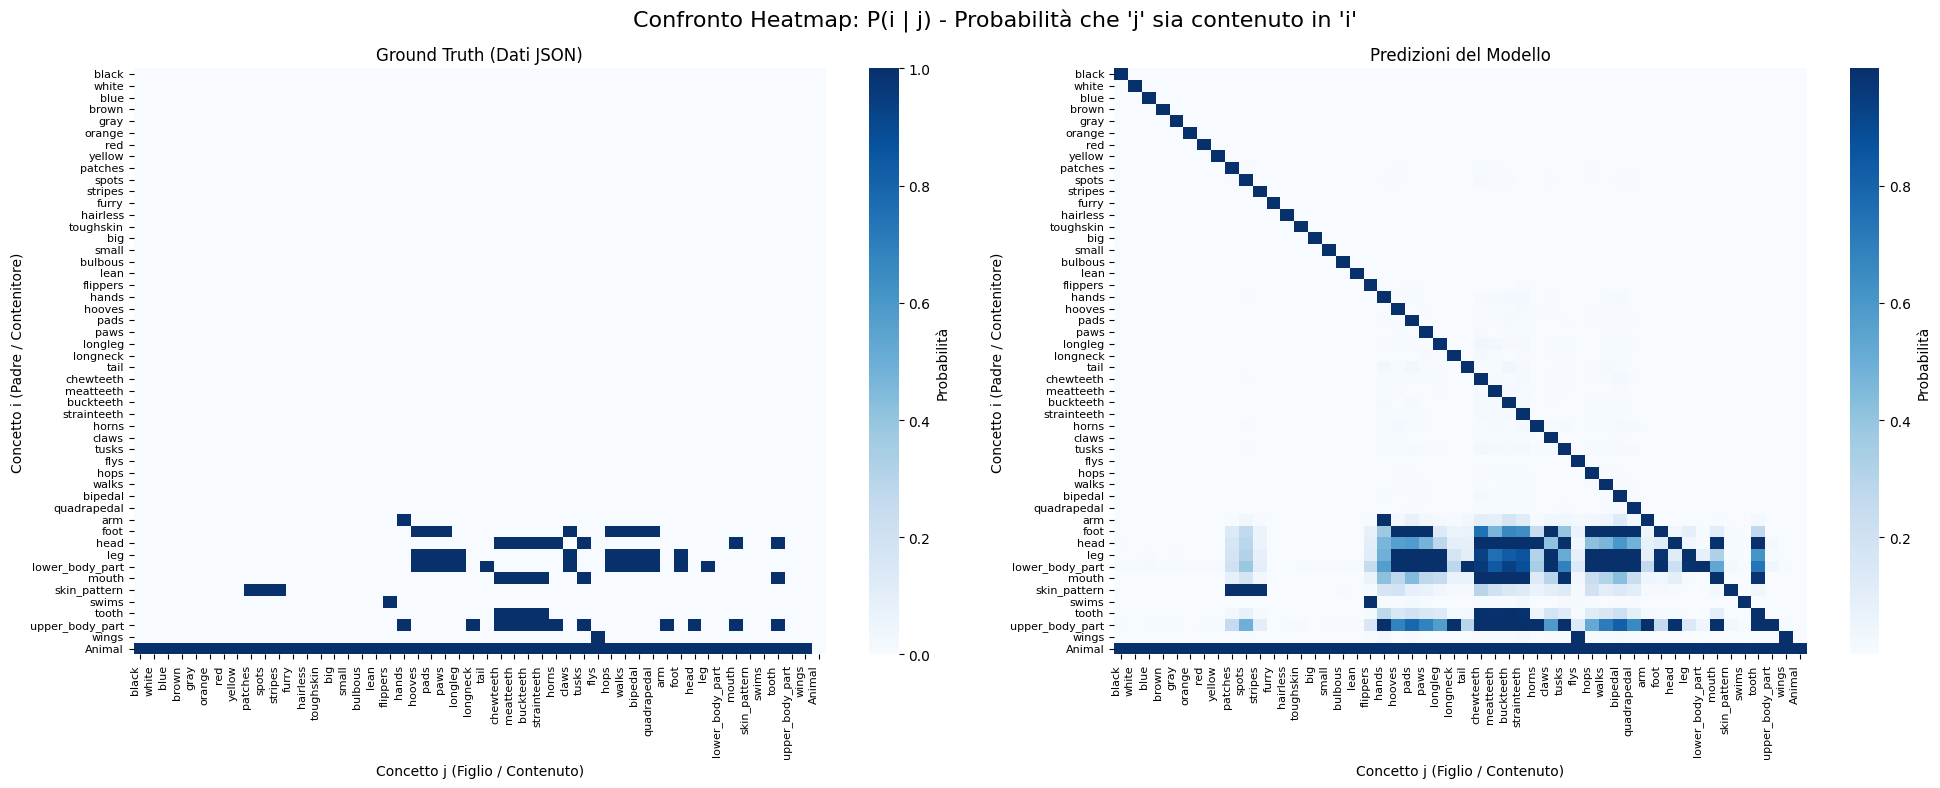

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

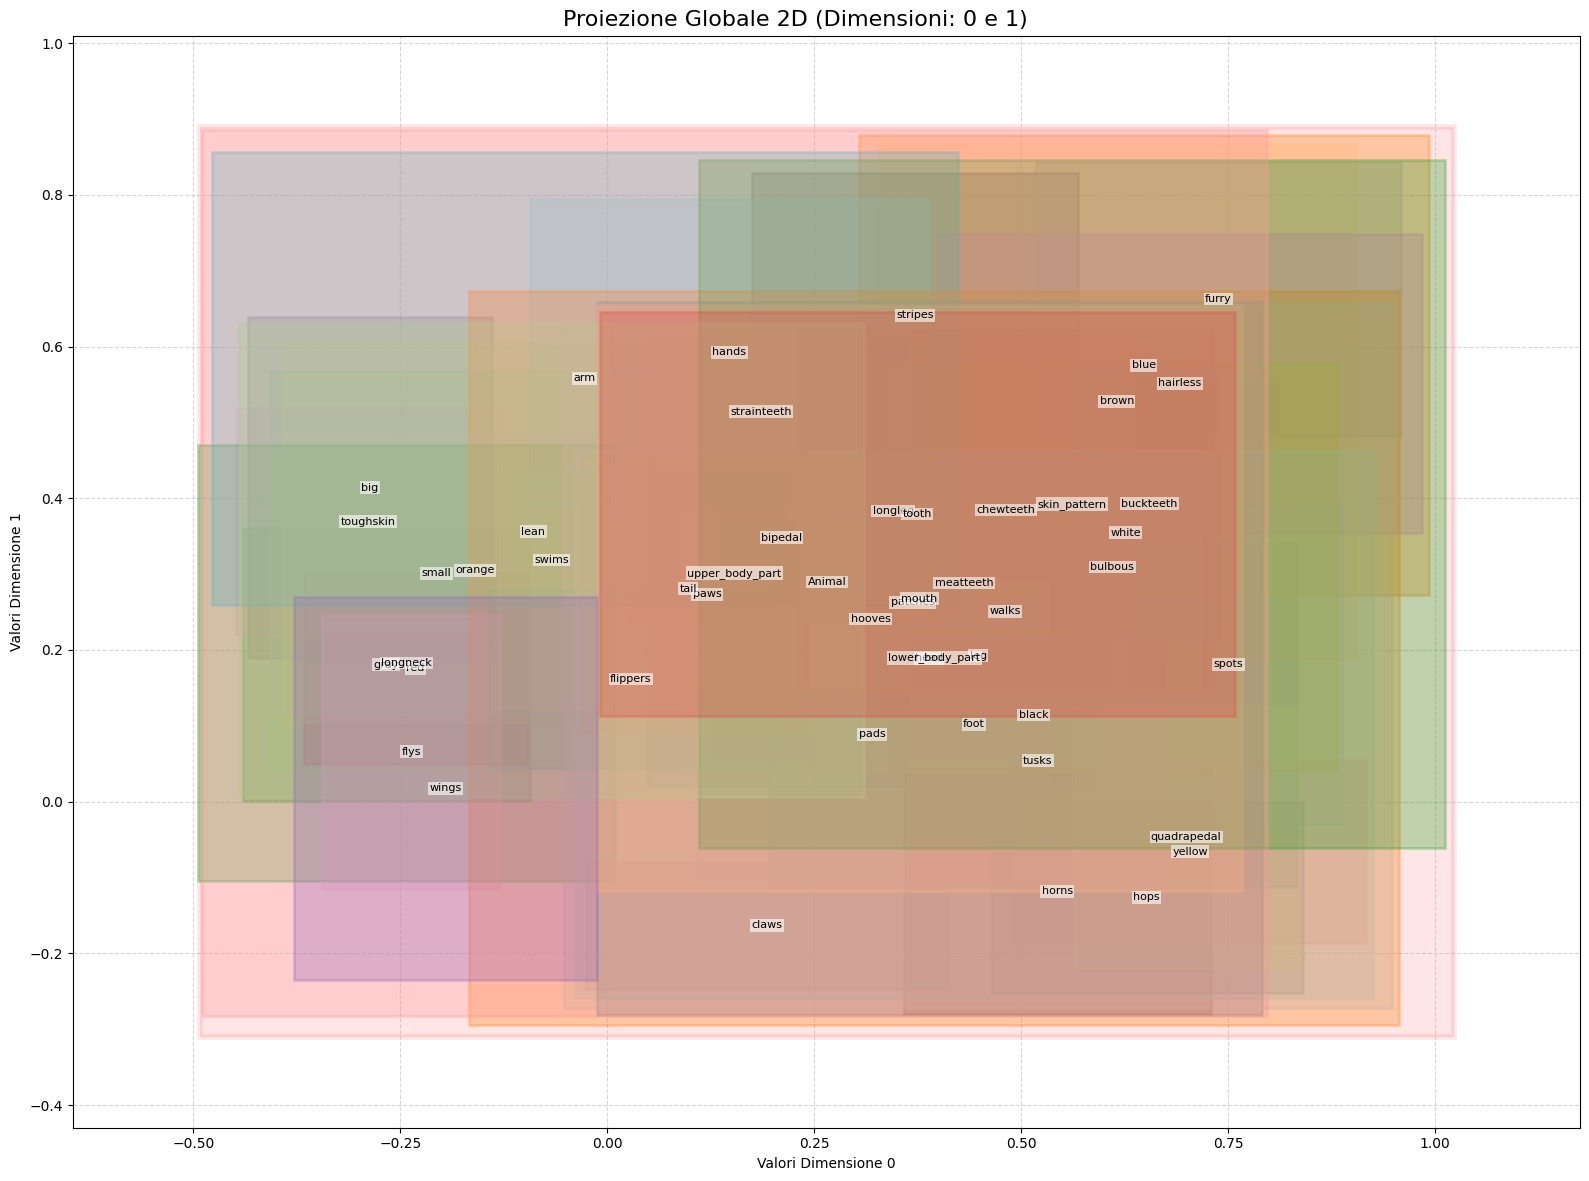

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

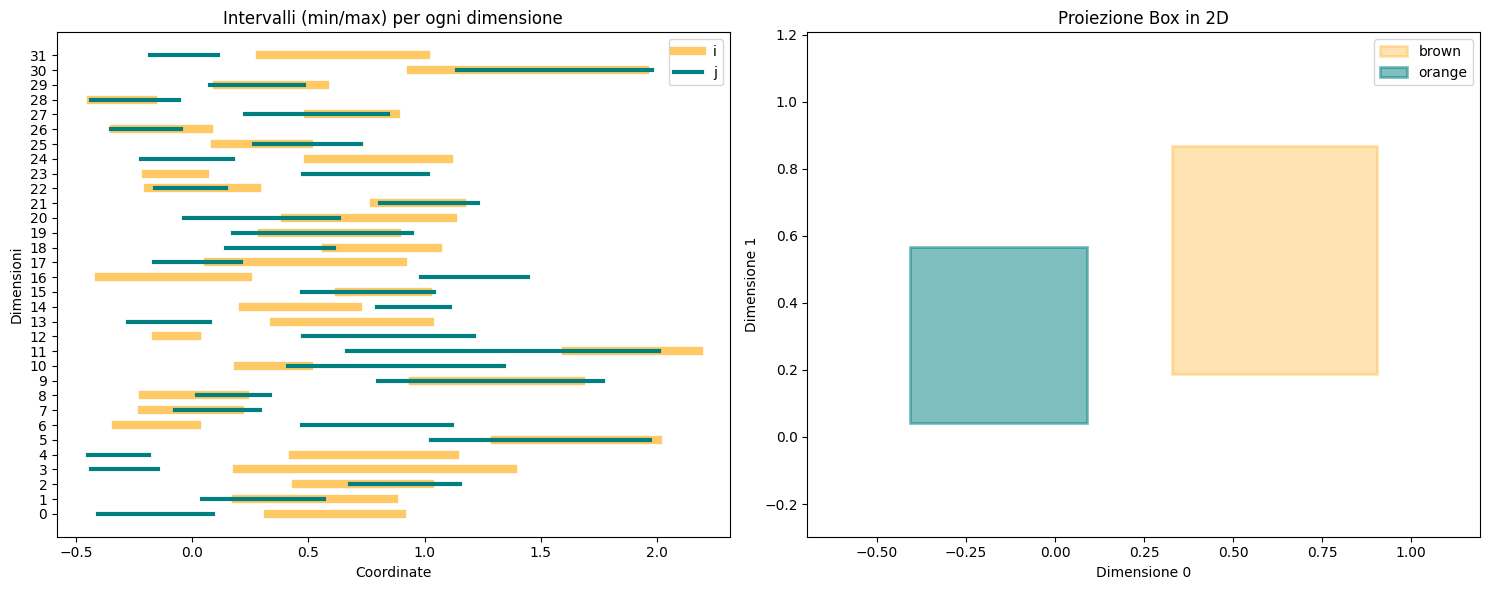

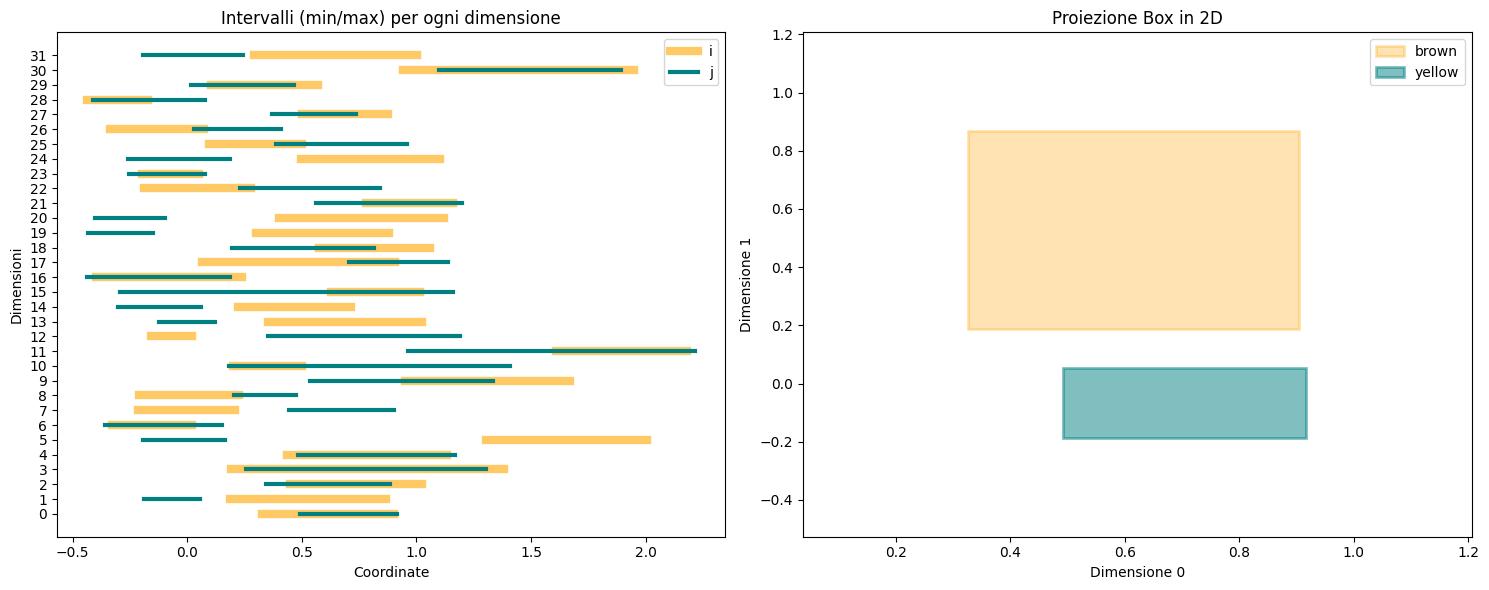

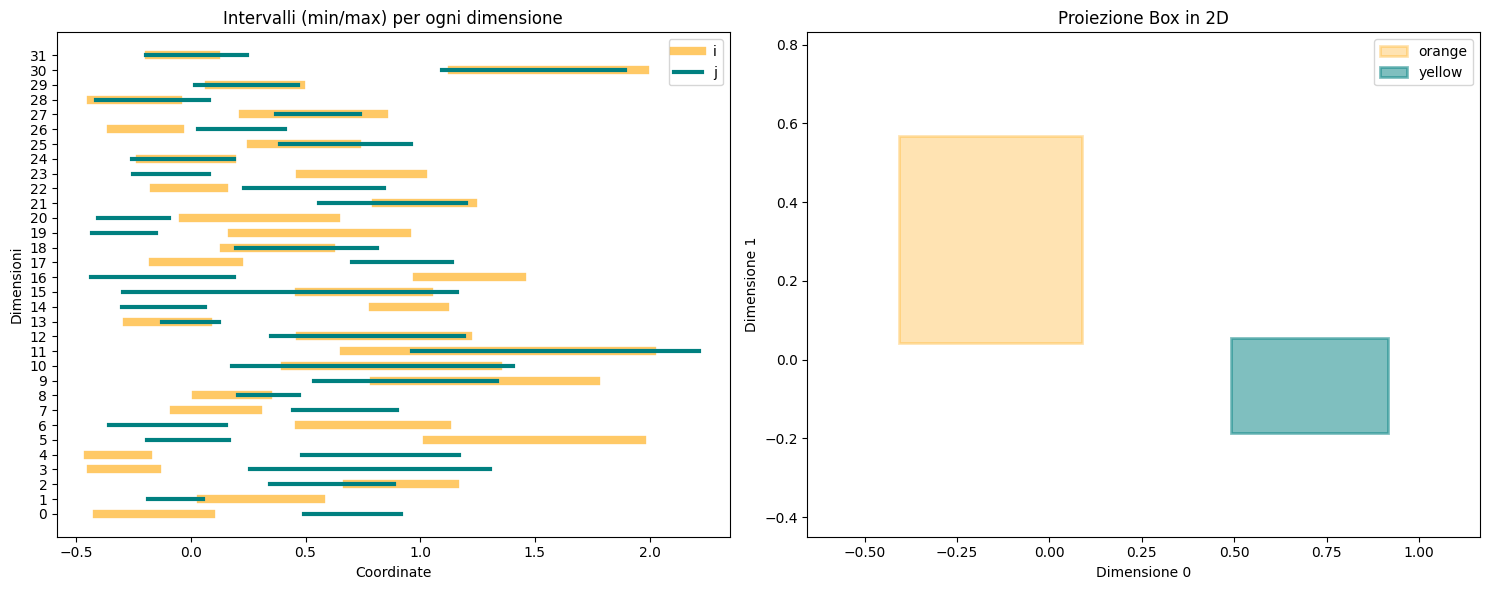

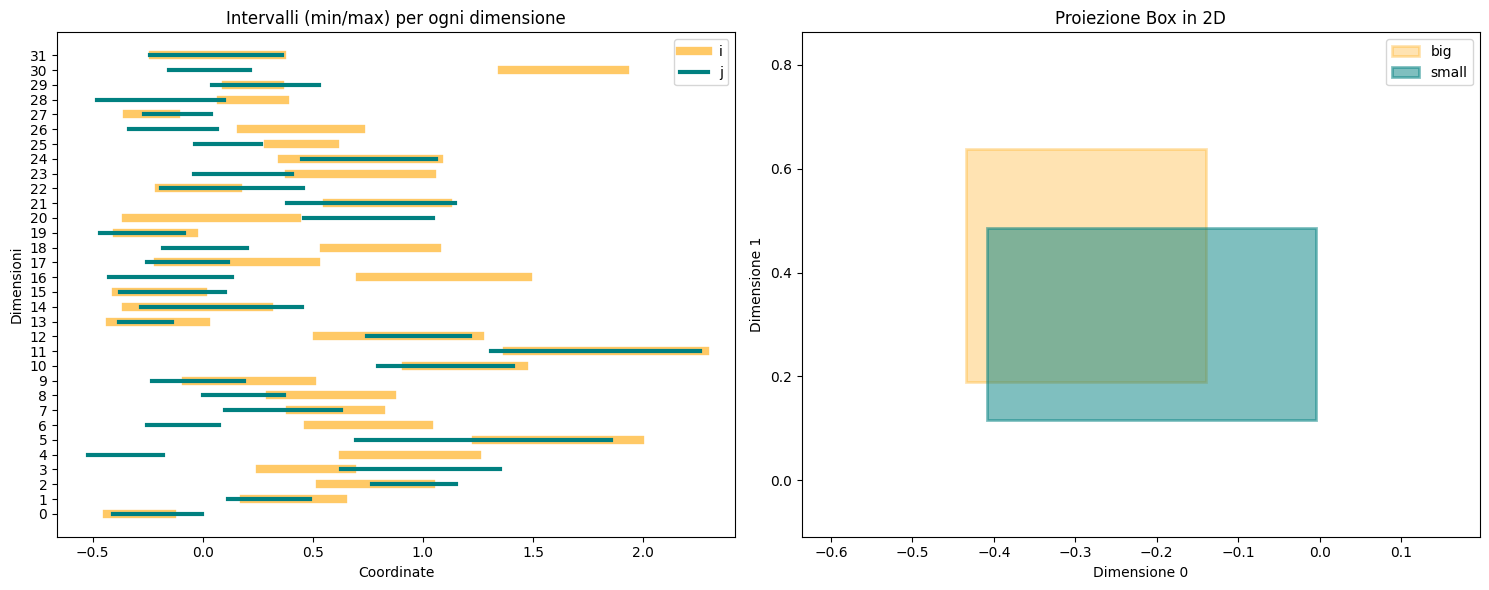

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0235, 0.8894, 1.1581, 1.4245, 1.2613, 2.0749, 1.1691, 0.9656, 0.9888,
         1.8420, 1.5118, 2.2901, 1.3373, 1.1401, 1.2064, 1.2176, 1.6117, 1.1432,
         1.1693, 1.0674, 1.1199, 1.2397, 1.0861, 1.1178, 1.2087, 1.0591, 1.1590,
         0.8858, 0.9983, 0.8912, 1.9936, 1.3752]])
Coordinate z (min) per 'wings': tensor([[-0.3783, -0.2348, -0.1703, -0.2086,  0.2826,  0.4494, -0.2841,  0.0306,
          0.0643,  0.7344,  0.6492,  0.5434, -0.2096, -0.0758, -0.3313, -0.2504,
          0.6797, -0.1390,  0.4590, -0.2864, -0.3801,  0.0147,  0.4634,  0.0300,
         -0.1125,  0.0648, -0.3451,  0.1193, -0.4346,  0.2776,  0.3827,  0.1779]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0235, 0.8894, 1.1581, 1.4245, 1.2613, 2.0749, 1.1691, 0.9656, 0.9888,
         1.8420, 1.5118, 2.2901, 1.3373, 1.1401, 1.2064, 1.2176, 1.6117, 1.1432,
         1.1693, 1.0674, 1.1199, 1.2397, 1.0861, 1.1178, 1.2087, 1.0591, 1.1590,
         0.8858, 0.9983, 0.8912, 1.9936, 1.3752]])
Coordinate z (min) per 'wings': tensor([[-0.3783, -0.2348, -0.1703, -0.2086,  0.2826,  0.4494, -0.2841,  0.0306,
          0.0643,  0.7344,  0.6492,  0.5434, -0.2096, -0.0758, -0.3313, -0.2504,
          0.6797, -0.1390,  0.4590, -0.2864, -0.3801,  0.0147,  0.4634,  0.0300,
         -0.1125,  0.0648, -0.3451,  0.1193, -0.4346,  0.2776,  0.3827,  0.1779]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results

### CBM with boxes

#### Train

In [ ]:
model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

In [ ]:
epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

#### Test

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors)

### CBM with cond prob distrib

#### Train

In [21]:
info = "rel_matrix"
model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=True
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=2.625, Acc=31.9% | VAL: Loss=2.133, Acc=49.9%
Epoca   3/20 | TRAIN: Loss=1.892, Acc=60.3% | VAL: Loss=1.681, Acc=69.6%
Epoca   4/20 | TRAIN: Loss=1.507, Acc=72.4% | VAL: Loss=1.362, Acc=71.0%
Epoca   5/20 | TRAIN: Loss=1.235, Acc=77.9% | VAL: Loss=1.119, Acc=81.8%
Epoca   6/20 | TRAIN: Loss=1.029, Acc=83.3% | VAL: Loss=0.950, Acc=82.7%
Epoca   7/20 | TRAIN: Loss=0.870, Acc=86.5% | VAL: Loss=0.797, Acc=88.7%
Epoca   8/20 | TRAIN: Loss=0.744, Acc=89.0% | VAL: Loss=0.686, Acc=92.5%
Epoca   9/20 | TRAIN: Loss=0.644, Acc=90.6% | VAL: Loss=0.595, Acc=92.1%
Epoca  10/20 | TRAIN: Loss=0.561, Acc=91.8% | VAL: Loss=0.528, Acc=92.6%
Epoca  11/20 | TRAIN: Loss=0.494, Acc=92.6% | VAL: Loss=0.462, Acc=96.1%
Epoca  12/20 | TRAIN: Loss=0.438, Acc=93.5% | VAL: Loss=0.409, Acc=96.9%
Epoca  13/20 | TRAIN: Loss=0.392, Acc=93.4% | VAL: Loss=0.368, Acc=93.5%
Epoca  14/20 | TRAIN: Loss=0.354, Acc=94.1% | VAL: Loss=0.336, Acc=94.1%

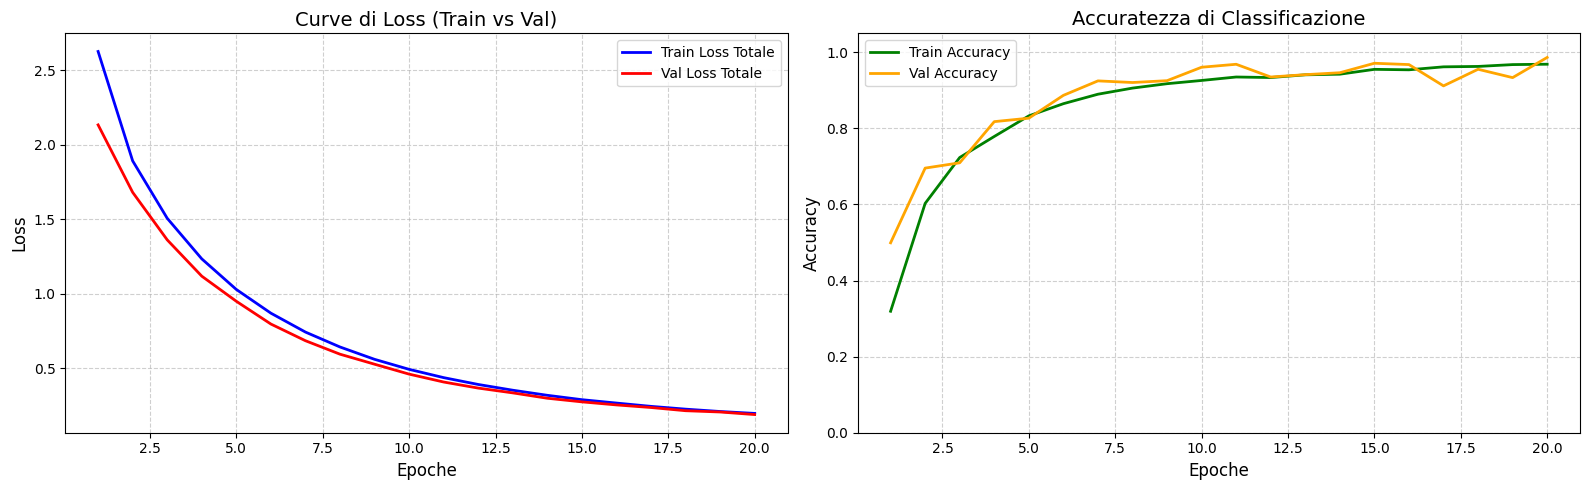

In [22]:
epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

#### Test

In [23]:
accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 98.66% (7365/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       0.67      1.00      0.81       207
           8       1.00      1.00      1.00        35
           9       0.00      0.00      0.00       100

   micro avg       0.93      0.93      0.93      1405
   macro avg       0.87      0.90      0.88      1405
weighted avg       0.88      0.93      0.90      1405



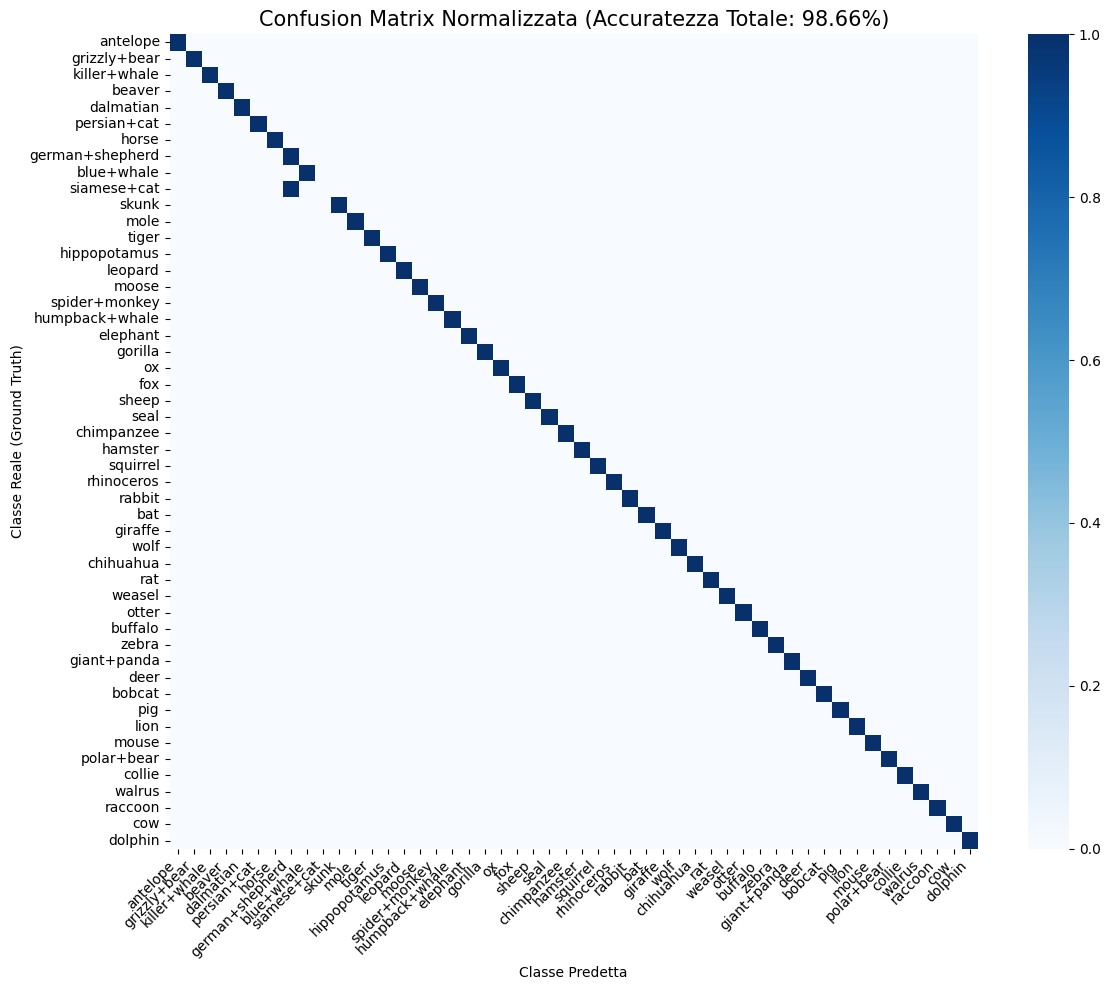


Analisi degli Errori Principali:
 - 100 volte: 'siamese+cat' è stato scambiato per 'german+shepherd'


In [24]:
plot_test_results(accuracy, preds, labels, class_names=classes)

1. controllare 100% accuracy sospetto
2. valutare istanza per istanza interpretazione
3. training x -> c_pred

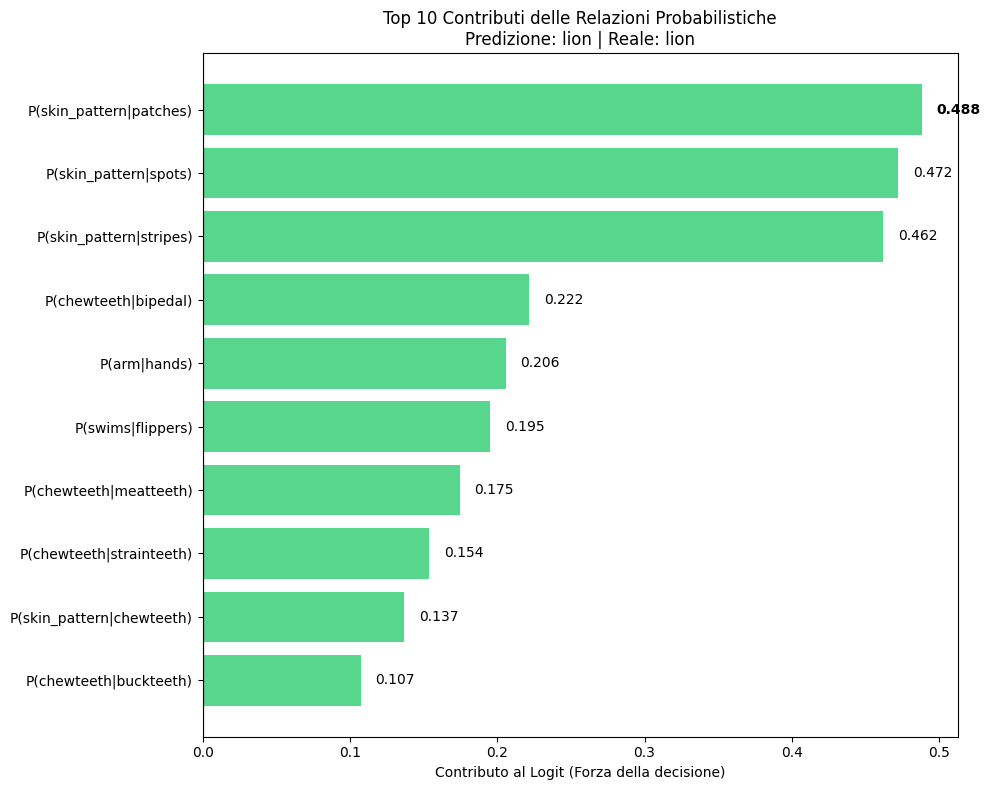

True

In [25]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info, target_class="lion", bipolar=True)

#### CBM standard

In [ ]:
info = "concepts"
model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)